In [62]:
import re
import random
import numpy as np
import matplotlib.pyplot as plt

text = [
    "The old cat sat on the windowsill and watched the rain fall.",
    "She opened the letter slowly, unsure of what she might find inside.",
    "By the time they reached the summit, the sun had already begun to set.",
]

# Tokenizer
A simple word-level tokenizer: text → token indexes → text.

## Functions

In [56]:
def tokenize(sentences):
    return [w for s in sentences for w in re.sub(r'[^\w\s]', '', s).lower().split()]

def get_vocabulary(sentences):
    return {word: i for i, word in enumerate(sorted(set(tokenize(sentences))))}

def encoder(words, vocab):
    if isinstance(words, str):
        words = words.split()
    return [vocab[word] for word in words]

def decoder(indexes, vocab):
    index_to_word = {i: word for word, i in vocab.items()}
    return ' '.join(index_to_word[i] for i in indexes)

def random_sentence(vocab, n=5):
    return decoder(random.sample(range(len(vocab)), n), vocab)

## Demo

In [57]:
vocab = get_vocabulary(text)

print("Vocab size:", len(vocab))
print("Random sentence:", random_sentence(vocab))
print("Round-trip:", decoder(encoder("the old cat", vocab), vocab))

Vocab size: 31
Random sentence: reached old set time she
Round-trip: the old cat


## Context Finder

In [59]:
def context_finder(token, sentences):
    words = tokenize(sentences)
    positions = [i for i, w in enumerate(words) if w == token]
    for pos in positions:
        prev = words[pos - 1] if pos > 0 else None
        next_ = words[pos + 1] if pos < len(words) - 1 else None
        print(f"[{pos}] '{prev}' → '{token}' → '{next_}'")
    return positions

context_finder("the", text)

[0] 'None' → 'the' → 'old'
[5] 'on' → 'the' → 'windowsill'
[9] 'watched' → 'the' → 'rain'
[14] 'opened' → 'the' → 'letter'
[25] 'by' → 'the' → 'time'
[29] 'reached' → 'the' → 'summit'
[31] 'summit' → 'the' → 'sun'


[0, 5, 9, 14, 25, 29, 31]

## Visualization

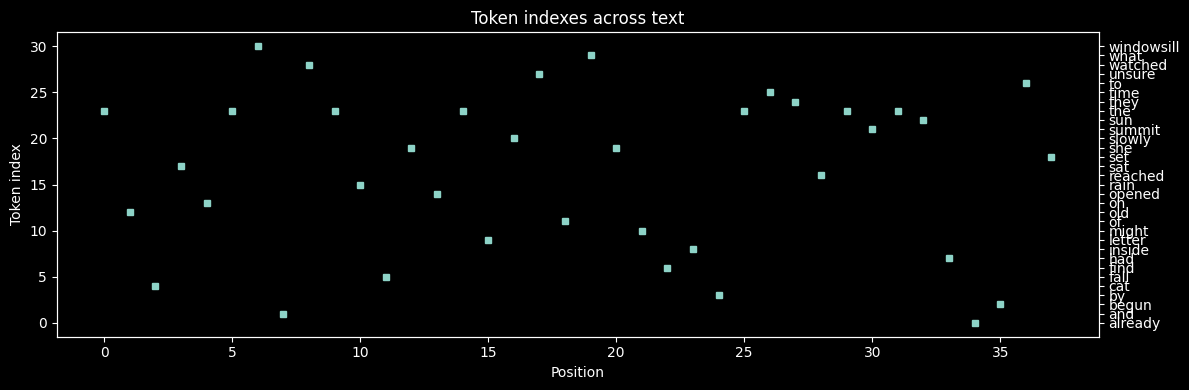

In [58]:
indexes = encoder(tokenize(text), vocab)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(indexes, 's', markersize=4)
ax.set_xlabel("Position")
ax.set_ylabel("Token index")
ax.set_title("Token indexes across text")

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(range(len(vocab)))
ax2.set_yticklabels(list(vocab.keys()))

plt.tight_layout()
plt.show()

## One-Hot Encoding

In [63]:
def one_hot_encode(sentences, vocab):
    words = tokenize(sentences)
    matrix = np.zeros((len(words), len(vocab)), dtype=int)
    for i, word in enumerate(words):
        matrix[i, vocab[word]] = 1
    return matrix

one_hot_encode(text, vocab)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(38, 31))

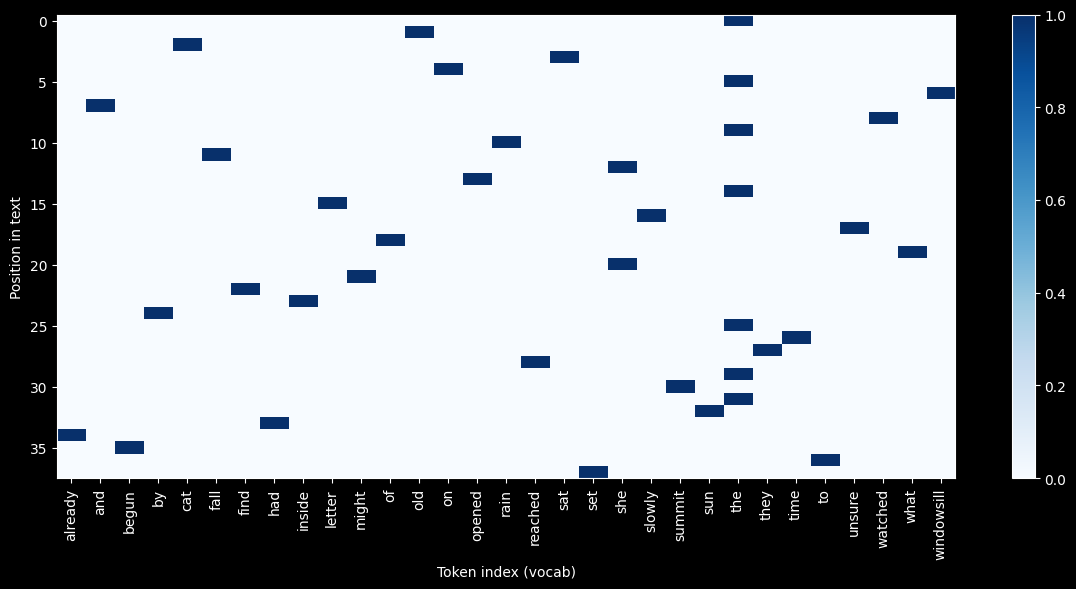

In [66]:
plt.figure(figsize=(12, 6))
plt.imshow(one_hot_encode(text,vocab), aspect='auto', cmap='Blues')
plt.xlabel("Token index (vocab)")
plt.ylabel("Position in text")
plt.xticks(range(len(vocab)), list(vocab.keys()), rotation=90)
plt.colorbar()
plt.tight_layout()
plt.show()